# import fly hemibrain data
***Notebook used to import fruit fly hemibrain connectome data and to filter fly connectivity to match sweat bee ROI***

In [2]:
import pandas as pd
import numpy as np
import json
import ast
import pickle

import neuprint as neu
from neuprint import Client, fetch_synapses, fetch_synapse_connections, NeuronCriteria as NC, SynapseCriteria as SC
from neuprint.client import setup_debug_logging
import navis
import navis.interfaces.neuprint as n_neu

from scipy.spatial import ConvexHull, convex_hull_plot_2d
import trimesh

In [3]:
# replace 'token' below with your token
# For instructions on obtaining neuprint token, see https://connectome-neuprint.github.io/neuprint-python/docs/quickstart.html

path = 'D:/flywire_backup/cave/neuprint.json' # replace with your path

with open(path, 'r') as f:
    token_file = json.load(f)
token = token_file['token']

client = neu.Client(
    "https://neuprint.janelia.org/",
    token=token,  
    dataset="hemibrain:v1.2.1"
)

In [4]:
# Show the ROI hierarchy, with primary ROIs marked with '*'
print(neu.fetch_roi_hierarchy(include_subprimary=True, mark_primary=True, format='text'))

hemibrain
 +-- AL(L)*
 |   +-- AL-D(L)
 |   +-- AL-DA2(L)
 |   +-- AL-DA3(L)
 |   +-- AL-DA4m(L)
 |   +-- AL-DC1(L)
 |   +-- AL-DC2(L)
 |   +-- AL-DC4(L)
 |   +-- AL-DL4(L)
 |   +-- AL-DL5(L)
 |   +-- AL-DM1(L)
 |   +-- AL-DM2(L)
 |   +-- AL-DM3(L)
 |   +-- AL-DM4(L)
 |   +-- AL-DM5(L)
 |   +-- AL-DM6(L)
 |   +-- AL-DP1m(L)
 |   +-- AL-VA6(L)
 |   +-- AL-VM7d(L)
 |   +-- AL-VM7v(L)
 +-- AL(R)*
 |   +-- AL-D(R)
 |   +-- AL-DA1(R)
 |   +-- AL-DA2(R)
 |   +-- AL-DA3(R)
 |   +-- AL-DA4l(R)
 |   +-- AL-DA4m(R)
 |   +-- AL-DC1(R)
 |   +-- AL-DC2(R)
 |   +-- AL-DC3(R)
 |   +-- AL-DC4(R)
 |   +-- AL-DL1(R)
 |   +-- AL-DL2d(R)
 |   +-- AL-DL2v(R)
 |   +-- AL-DL3(R)
 |   +-- AL-DL4(R)
 |   +-- AL-DL5(R)
 |   +-- AL-DM1(R)
 |   +-- AL-DM2(R)
 |   +-- AL-DM3(R)
 |   +-- AL-DM4(R)
 |   +-- AL-DM5(R)
 |   +-- AL-DM6(R)
 |   +-- AL-DP1l(R)
 |   +-- AL-DP1m(R)
 |   +-- AL-V(R)
 |   +-- AL-VA1d(R)
 |   +-- AL-VA1v(R)
 |   +-- AL-VA2(R)
 |   +-- AL-VA3(R)
 |   +-- AL-VA4(R)
 |   +-- AL-VA5(R)
 |   +-- A

In [6]:
# obtain all HD neurons (GLNO and LNO not used in analysis, but included here)
source = NC(type='EPG.*|PEG.*|PEN_a.*|PEN_b.*|Delta7.*|ER.*|GLNO.*|LNO.*', regex=True)
source_info, source_conn = neu.fetch_neurons(source)

target =  NC(type='EPG.*|PEG.*|PEN_a.*|PEN_b.*|Delta7.*|ER.*|GLNO.*|LNO.*', regex=True)
target_info, target_conn = neu.fetch_neurons(target)

print(source_info.head()) # check 

# for fly synapse table
# Merge 'type' and 'instance' from source_info into source_conn based on 'bodyId'

source_conn = source_conn.merge(
    source_info[['bodyId', 'type', 'instance']],
    on='bodyId',
    how='left'  # Use 'inner' if you only want rows that match
)

print(source_conn.head())

      bodyId         instance         type  pre  post  downstream  upstream  \
0  387023620  PEN_b(PB06b)_L4  PEN_b(PEN2)  343  1713        1657      1713   
1  387364605     EPG(PB08)_L3          EPG  645  4350        3725      4350   
2  416642425     EPG(PB08)_R4          EPG  470  3834        2869      3834   
3  449438847     EPG(PB08)_L3          EPG  609  4595        3640      4595   
4  478375456     EPG(PB08)_R3          EPG  483  4249        2802      4249   

   mito        size  status  cropped     statusLabel cellBodyFiber  \
0   185   686693145  Traced    False  Roughly traced         PDM02   
1   295  1469716322  Traced    False  Roughly traced         PDM01   
2   208  1169220265  Traced    False  Roughly traced         PDM02   
3   272  1356917252  Traced    False  Roughly traced         PDM01   
4   253  1290806813  Traced    False  Roughly traced         PDM01   

   somaRadius          somaLocation  \
0       339.0  [28739, 18461, 6144]   
1       348.5  [28767, 190

In [7]:
# to obtain fy connectivity table
source_list = source_info['bodyId'].tolist()
target_list = target_info['bodyId'].tolist()
neuron_df, conn_df = neu.fetch_adjacencies(sources=source_list, targets=target_list)

conn_df = neu.merge_neuron_properties(neuron_df, conn_df, ['type', 'instance'])

unique_count_source = source_info['bodyId'].nunique()
unique_count_target = target_info['bodyId'].nunique()
unique_count_fetched = neuron_df['bodyId'].nunique()

print(f'{unique_count_source} unique source neurons, {unique_count_source} unique target, {unique_count_fetched} neurons fetched total')

# save local copies of tables
source_info.to_csv('../../data/fly_hemibrain_sourceinfo.csv', index=False)
target_info.to_csv('../../data/fly_hemibrain_targetinfo.csv', index=False)
conn_df.to_csv('../../data/fly_hemibrain_conntable_unannotated.csv', index=False)

  0%|          | 0/3 [00:00<?, ?it/s]

422 unique source neurons, 422 unique target, 422 neurons fetched total


In [10]:
conn_df = pd.read_csv('../../data/fly_hemibrain_conntable_unannotated.csv')
source_info = pd.read_csv('../../data/fly_hemibrain_sourceinfo.csv')
target_info = pd.read_csv('../../data/fly_hemibrain_targetinfo.csv')

source_info['roiInfo'] = source_info['roiInfo'].apply(ast.literal_eval)
target_info['roiInfo'] = target_info['roiInfo'].apply(ast.literal_eval)

In [11]:
# goal obtain total number of postsynaptic synapses within a ROI for each neuron

# this can be used to calculate the relative weights (though it isn't currently used in manuscript)
# add total postsynaptic column total_post_syn
neuron_info = pd.concat([source_info, target_info])

flat_rows = []
for entry in neuron_info.roiInfo:
    flat_row = {}
    for roi, counts in entry.items():
        for k, v in counts.items():
            flat_row[f"{roi}_{k}"] = v
    flat_rows.append(flat_row)

flat_df = pd.DataFrame(flat_rows).reset_index(drop=True)
neuron_info = neuron_info.reset_index(drop=True)

neuron_info['PB_post'] = flat_df['PB_post']
neuron_info['EB_post'] = flat_df['EB_post']
neuron_info['NO_post'] = flat_df['NO_post']

neuron_info_unique = neuron_info[['bodyId','PB_post','EB_post','NO_post']].drop_duplicates('bodyId') # drop duplicates

example_neuron = neuron_info[neuron_info['bodyId'] == 508793049]
print(example_neuron['NO_post'])


5      505.0
427    505.0
Name: NO_post, dtype: float64


In [12]:
# perform a left join using bodyId_post <-> bodyId
conn_df = conn_df.merge(
    neuron_info_unique[['bodyId', 'PB_post', 'EB_post', 'NO_post']],   # roi_post == total # of syn in that ROI
    left_on='bodyId_post', 
    right_on='bodyId', 
    how='left'
)

# drop the redundant 'bodyId' column added by the merge
conn_df = conn_df.drop(columns=['bodyId'])

cols = ['PB_post', 'EB_post', 'NO_post']
conn_df[cols] = conn_df[cols].fillna(0).astype(int)

conn_df

,bodyId_pre,bodyId_post,roi,weight,type_pre,instance_pre,type_post,instance_post,PB_post,EB_post,NO_post
0,387023620,387364605,EB,66,PEN_b(PEN2),PEN_b(PB06b)_L4,EPG,EPG(PB08)_L3,265,3892,0
1,387023620,449438847,EB,52,PEN_b(PEN2),PEN_b(PB06b)_L4,EPG,EPG(PB08)_L3,331,4070,0
2,387023620,508793049,NO,6,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_a(PEN1),PEN_a(PB06a)_L7,274,814,505
3,387023620,539462336,NO,30,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_b(PEN2),PEN_b(PB06b)_L4,698,520,388
4,387023620,539462336,EB,8,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_b(PEN2),PEN_b(PB06b)_L4,698,520,388
...,...,...,...,...,...,...,...,...,...,...,...
46043,5813080979,5813047793,EB,2,PEN_a(PEN1),PEN_a(PB06a)_L5,ER4m,ER4m(ring)_L,0,1522,0
46044,5813080979,5813049948,EB,2,PEN_a(PEN1),PEN_a(PB06a)_L5,ER4m,ER4m(ring)_L,0,1562,0
46045,5813080979,5813053866,EB,6,PEN_a(PEN1),PEN_a(PB06a)_L5,ER4m,ER4m(ring)_R,0,1685,0
46046,5813080979,5813059835,EB,4,PEN_a(PEN1),PEN_a(PB06a)_L5,ER1_a,ER1_a(ring)_L,0,449,0


In [13]:
fly_count = conn_df.copy()

fly_count = fly_count.rename(columns={'weight':'count'})
# (don't do) update PEN_a to PEN1 and PEN_b to PEN2
# fly_count['instance_pre'] = fly_count['instance_pre'].str.replace(r'^PEN_a', 'PEN1', regex=True)
# fly_count['instance_pre'] = fly_count['instance_pre'].str.replace(r'^PEN_b', 'PEN2', regex=True)
# fly_count['instance_post'] = fly_count['instance_post'].str.replace(r'^PEN_a', 'PEN1', regex=True)
# fly_count['instance_post'] = fly_count['instance_post'].str.replace(r'^PEN_b', 'PEN2', regex=True)

# fly_count['type_pre'] = fly_count['type_pre'].str.replace(r'^PEN_a', 'PEN1', regex=True)
# fly_count['type_pre'] = fly_count['type_pre'].str.replace(r'^PEN_b', 'PEN2', regex=True)
# fly_count['type_post'] = fly_count['type_post'].str.replace(r'^PEN_a', 'PEN1', regex=True)
# fly_count['type_post'] = fly_count['type_post'].str.replace(r'^PEN_b', 'PEN2', regex=True)

####################################
####################################

# add column for relative weights: take synapses from neuron a to neuron b in region X and divided this 
# number by the total number of inputs that neuron b received in X

fly_count['bodyId_pre'] = fly_count['bodyId_pre'].astype(str)
fly_count['bodyId_post'] = fly_count['bodyId_post'].astype(str)

####################################
####################################
# relative weights are not used in manuscript

# def compute_relative_weight(row, roi_name):
#     if row['roi'] == roi_name:
#         denom = row.get(f'{roi_name}_post', np.nan)
#         if denom == 0 or pd.isna(denom):
#             return 0.0
#         return row['count'] / denom
#     else:
#         return 0.0

# fly_count['relative_weight_PB'] = fly_count.apply(lambda row: compute_relative_weight(row, 'PB'), axis=1)
# fly_count['relative_weight_EB'] = fly_count.apply(lambda row: compute_relative_weight(row, 'EB'), axis=1)
# fly_count['relative_weight_NO'] = fly_count.apply(lambda row: compute_relative_weight(row, 'NO'), axis=1)

# ####################################
# ####################################
# Regex patterns
pattern_standard = r'^([A-Z]{3}[a-zA-Z]?(?:\d+)?(?:_[a-z])?).*(R\d|L\d)'
pattern_er = r'^(ER\d+[a-z]?)(?:_([a-z]))?\(ring\)_([LR])$'
pattern_d7 = r'(?i)(Delta7).*?_(L\d(?:[LR]\d)+)'
pattern_lno = r'(LNO3|LNO2|LNO1|LNOa|GLNO)'

# Extract for standard neurons
extracted_pre_standard = fly_count['instance_pre'].str.extract(pattern_standard)
extracted_post_standard = fly_count['instance_post'].str.extract(pattern_standard)

# Extract for delta7 neurons
extracted_pre_d7 = fly_count['instance_pre'].str.extract(pattern_d7)
extracted_post_d7 = fly_count['instance_post'].str.extract(pattern_d7)

# Extract for lno neurons
extracted_lno_pre = fly_count['type_pre'].str.extract(pattern_lno)
extracted_lno_post = fly_count['type_post'].str.extract(pattern_lno)

# Extract for ER neurons
extracted_pre_er = fly_count['instance_pre'].str.extract(pattern_er)
extracted_post_er = fly_count['instance_post'].str.extract(pattern_er)

# precompute the fully constructed strings for each pattern
d7_type_pre = extracted_pre_d7[0] + '_' + extracted_pre_d7[1]
d7_type_post = extracted_post_d7[0] + '_' + extracted_post_d7[1]

er_type_pre = extracted_pre_er[0] + extracted_pre_er[1].fillna('') + '_' + extracted_pre_er[2]
er_type_post = extracted_post_er[0] + extracted_post_er[1].fillna('') + '_' + extracted_post_er[2]

std_type_pre = extracted_pre_standard[0] + '_' + extracted_pre_standard[1]
std_type_post = extracted_post_standard[0] + '_' + extracted_post_standard[1]


# assign type (e.g., only the class, not location info)
fly_count['type_pre'] = extracted_pre_er[0].combine_first(extracted_pre_standard[0]).combine_first(extracted_pre_d7[0]).combine_first(extracted_lno_pre[0])
fly_count['type_post'] = extracted_post_er[0].combine_first(extracted_post_standard[0]).combine_first(extracted_post_d7[0]).combine_first(extracted_lno_post[0])

fly_count['type_pre_col'] = er_type_pre.combine_first(std_type_pre).combine_first(d7_type_pre).combine_first(extracted_lno_pre[0])
fly_count['type_post_col'] = er_type_post.combine_first(std_type_post).combine_first(d7_type_post).combine_first(extracted_lno_post[0])

# # final naming
fly_count['pre_name'] = fly_count['type_pre_col'] + '_' + fly_count['bodyId_pre'].astype(str)
fly_count['post_name'] = fly_count['type_post_col'] + '_' + fly_count['bodyId_post'].astype(str)

fly_count

,bodyId_pre,bodyId_post,roi,count,type_pre,instance_pre,type_post,instance_post,PB_post,EB_post,NO_post,type_pre_col,type_post_col,pre_name,post_name
0,387023620,387364605,EB,66,PEN_b,PEN_b(PB06b)_L4,EPG,EPG(PB08)_L3,265,3892,0,PEN_b_L4,EPG_L3,PEN_b_L4_387023620,EPG_L3_387364605
1,387023620,449438847,EB,52,PEN_b,PEN_b(PB06b)_L4,EPG,EPG(PB08)_L3,331,4070,0,PEN_b_L4,EPG_L3,PEN_b_L4_387023620,EPG_L3_449438847
2,387023620,508793049,NO,6,PEN_b,PEN_b(PB06b)_L4,PEN_a,PEN_a(PB06a)_L7,274,814,505,PEN_b_L4,PEN_a_L7,PEN_b_L4_387023620,PEN_a_L7_508793049
3,387023620,539462336,NO,30,PEN_b,PEN_b(PB06b)_L4,PEN_b,PEN_b(PB06b)_L4,698,520,388,PEN_b_L4,PEN_b_L4,PEN_b_L4_387023620,PEN_b_L4_539462336
4,387023620,539462336,EB,8,PEN_b,PEN_b(PB06b)_L4,PEN_b,PEN_b(PB06b)_L4,698,520,388,PEN_b_L4,PEN_b_L4,PEN_b_L4_387023620,PEN_b_L4_539462336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46043,5813080979,5813047793,EB,2,PEN_a,PEN_a(PB06a)_L5,ER4m,ER4m(ring)_L,0,1522,0,PEN_a_L5,ER4m_L,PEN_a_L5_5813080979,ER4m_L_5813047793
46044,5813080979,5813049948,EB,2,PEN_a,PEN_a(PB06a)_L5,ER4m,ER4m(ring)_L,0,1562,0,PEN_a_L5,ER4m_L,PEN_a_L5_5813080979,ER4m_L_5813049948
46045,5813080979,5813053866,EB,6,PEN_a,PEN_a(PB06a)_L5,ER4m,ER4m(ring)_R,0,1685,0,PEN_a_L5,ER4m_R,PEN_a_L5_5813080979,ER4m_R_5813053866
46046,5813080979,5813059835,EB,4,PEN_a,PEN_a(PB06a)_L5,ER1,ER1_a(ring)_L,0,449,0,PEN_a_L5,ER1a_L,PEN_a_L5_5813080979,ER1a_L_5813059835


***IMPORTANT: for comparing synapses between sweat bee and fly, use 'downstream' and 'upstream', not 'pre' and 'post'***

In [14]:
# export
fly_count.to_csv('../../data/fly_hemibrain_all_hd_cells_conntable.csv', index=False)

# filter fly syntable and connectivity table to match ROI included in sweat bee analysis
- make subvolumes of EB and PB and filter synapses within
- Fly hemibrain columnar cells have annotations for PB columns, but not for EB columns. Below, I use the branches of EPGs within the EB to extract a subvolume that contains EBc1 and EBc2.

In [15]:
### generate proper fly synapse table
n = NC(type='EPG.*|PEG.*|PEN_a.*|PEN_b.*|Delta7.*|ER.*', regex = True)
n_info, n_conn = neu.fetch_neurons(n)

In [16]:
# obtain list of bodyIDs for all neurons included in HD analysis
PB_col = n_info[n_info['instance'].str.contains(r'^(EPG|PEG|PEN).*_L[3-6]$')]
PB_d7 = n_info[n_info['instance'].str.contains(r'Delta')]

pbcol_list = PB_col['bodyId'].unique().tolist()
PB_d7_list = PB_d7['bodyId'].unique().tolist()

pat = r'^(EPG|EPGt|PEG).*_(L[1-2]|R[8-9])$|^PEN.*_(L[2-3]|R[8-9])$'

EB_col = n_info[n_info['instance'].str.contains(pat, regex=True)]
EB_er = n_info[n_info['instance'].str.contains(r'ER', regex=True)]

ebcol_list = EB_col['bodyId'].unique().tolist()
eber_list = EB_er['bodyId'].unique().tolist()

bodyId_list = pbcol_list + PB_d7_list + ebcol_list + eber_list

bodyId_list = list(set(bodyId_list))

bodyId_list

C:\Users\Marcel\AppData\Local\Temp\ipykernel_6892\1038003520.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PB_col = n_info[n_info['instance'].str.contains(r'^(EPG|PEG|PEN).*_L[3-6]$')]
C:\Users\Marcel\AppData\Local\Temp\ipykernel_6892\1038003520.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  EB_col = n_info[n_info['instance'].str.contains(pat, regex=True)]


[1601771527,
 973959177,
 942522378,
 1106180107,
 1261086734,
 1199712272,
 1322133531,
 1322129437,
 1261086755,
 1261086756,
 1261764651,
 1169260589,
 1260828727,
 1198680122,
 1231079482,
 1230712894,
 1293135946,
 1292847181,
 5812983887,
 1322137688,
 1291444314,
 911911004,
 1261086823,
 911906936,
 1230712956,
 1261768832,
 1167632513,
 634962055,
 1380495496,
 1261086863,
 5813047446,
 1261768859,
 1261772956,
 1229965474,
 1261768880,
 1136861363,
 912601268,
 1292816565,
 1198680249,
 910796989,
 1293136062,
 1322129610,
 5813080269,
 1261773006,
 5813080272,
 1261768913,
 880875736,
 5812984024,
 910442723,
 819828986,
 5813059834,
 5813059835,
 910442752,
 1199427845,
 1168064774,
 1322133768,
 1168392468,
 911911193,
 910442782,
 1261773104,
 1261091124,
 1231675708,
 541870397,
 1322129724,
 1292458303,
 1322133825,
 1322129730,
 1260327246,
 880875861,
 1261091157,
 5813047647,
 1322133858,
 1261091174,
 1198680426,
 1167563121,
 1322129781,
 1198680441,
 1292458366,
 

In [17]:
rois = ['EB', 'PB', 'NO'] # 'PB(L3)', 'PB(L4)', 'PB(L5)', 'PB(L6)'

n_criteria = NC(bodyId=bodyId_list, regex=True, rois=rois, roi_req='any')

s_criteria = SC(rois=rois, primary_only=True) # include_nonprimary=True

syntable = fetch_synapse_connections(n_criteria, n_criteria, s_criteria)
syntable.head()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/300230 [00:00<?, ?it/s]

,bodyId_pre,bodyId_post,roi_pre,roi_post,x_pre,y_pre,z_pre,x_post,y_post,z_post,confidence_pre,confidence_post
0,5813080979,387023620,NO,NO,25513,23688,23388,25517,23679,23397,0.929,0.880456
1,5813070465,387023620,NO,NO,24835,22927,23457,24834,22913,23444,0.778,0.813000
2,5813070465,387023620,NO,NO,25133,22742,23248,25127,22717,23240,0.912,0.870472
3,5813070465,387023620,NO,NO,24505,22960,22950,24525,22987,22964,0.966,0.643949
4,5813070465,387023620,NO,NO,24800,22873,23390,24821,22868,23385,0.883,0.663000


In [18]:
syns = neu.merge_neuron_properties(n_info, syntable, ['type', 'instance'])

# save local copy
syns.to_csv('../../data/fly_hemibrain_syntable_unannotated.csv', index=False)

syns

,bodyId_pre,bodyId_post,roi_pre,roi_post,x_pre,y_pre,z_pre,x_post,y_post,z_post,confidence_pre,confidence_post,type_pre,instance_pre,type_post,instance_post
0,5813080979,387023620,NO,NO,25513,23688,23388,25517,23679,23397,0.929,0.880456,PEN_a(PEN1),PEN_a(PB06a)_L5,PEN_b(PEN2),PEN_b(PB06b)_L4
1,5813070465,387023620,NO,NO,24835,22927,23457,24834,22913,23444,0.778,0.813000,PEN_b(PEN2),PEN_b(PB06b)_L3,PEN_b(PEN2),PEN_b(PB06b)_L4
2,5813070465,387023620,NO,NO,25133,22742,23248,25127,22717,23240,0.912,0.870472,PEN_b(PEN2),PEN_b(PB06b)_L3,PEN_b(PEN2),PEN_b(PB06b)_L4
3,5813070465,387023620,NO,NO,24505,22960,22950,24525,22987,22964,0.966,0.643949,PEN_b(PEN2),PEN_b(PB06b)_L3,PEN_b(PEN2),PEN_b(PB06b)_L4
4,5813070465,387023620,NO,NO,24800,22873,23390,24821,22868,23385,0.883,0.663000,PEN_b(PEN2),PEN_b(PB06b)_L3,PEN_b(PEN2),PEN_b(PB06b)_L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300225,387023620,5813080979,NO,NO,25036,22370,23166,25044,22370,23157,0.627,0.999000,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_a(PEN1),PEN_a(PB06a)_L5
300226,387023620,5813080979,NO,NO,25392,22741,23505,25428,22735,23517,0.905,0.594787,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_a(PEN1),PEN_a(PB06a)_L5
300227,387023620,5813080979,NO,NO,25752,23233,23146,25743,23238,23136,0.664,0.965000,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_a(PEN1),PEN_a(PB06a)_L5
300228,387023620,5813080979,NO,NO,24742,23104,23375,24733,23117,23364,0.864,0.781266,PEN_b(PEN2),PEN_b(PB06b)_L4,PEN_a(PEN1),PEN_a(PB06a)_L5


In [19]:
# format table
# syns = pd.read_csv('../../data/fly_hemibrain_syntable_unannotated.csv')
fly_syns = syns.copy()

# ####################################
# ####################################
# Regex patterns
pattern_standard = r'^([A-Z]{3}[a-zA-Z]?(?:\d+)?(?:_[a-z])?).*(R\d|L\d)'
pattern_er = r'^(ER\d+[a-z]?)(?:_([a-z]))?\(ring\)_([LR])$'
pattern_d7 = r'(?i)(Delta7).*?_(L\d(?:[LR]\d)+)'
pattern_lno = r'(LNO3|LNO2|LNO1|LNOa|GLNO)' # not needed here

# Extract for standard neurons
extracted_pre_standard = fly_syns['instance_pre'].str.extract(pattern_standard)
extracted_post_standard = fly_syns['instance_post'].str.extract(pattern_standard)

# Extract for delta7 neurons
extracted_pre_d7 = fly_syns['instance_pre'].str.extract(pattern_d7)
extracted_post_d7 = fly_syns['instance_post'].str.extract(pattern_d7)

# Extract for lno neurons
extracted_lno_pre = fly_syns['type_pre'].str.extract(pattern_lno)
extracted_lno_post = fly_syns['type_post'].str.extract(pattern_lno)

# Extract for ER neurons
extracted_pre_er = fly_syns['instance_pre'].str.extract(pattern_er)
extracted_post_er = fly_syns['instance_post'].str.extract(pattern_er)


# precompute the fully constructed strings for each pattern
d7_type_pre = extracted_pre_d7[0] + '_' + extracted_pre_d7[1]
d7_type_post = extracted_post_d7[0] + '_' + extracted_post_d7[1]

er_type_pre = extracted_pre_er[0] + extracted_pre_er[1].fillna('') + '_' + extracted_pre_er[2]
er_type_post = extracted_post_er[0] + extracted_post_er[1].fillna('') + '_' + extracted_post_er[2]

std_type_pre = extracted_pre_standard[0] + '_' + extracted_pre_standard[1]
std_type_post = extracted_post_standard[0] + '_' + extracted_post_standard[1]


# assign type (e.g., only the class, not location info)
fly_syns['type_pre'] = extracted_pre_er[0].combine_first(extracted_pre_standard[0]).combine_first(extracted_pre_d7[0]).combine_first(extracted_lno_pre[0])
fly_syns['type_post'] = extracted_post_er[0].combine_first(extracted_post_standard[0]).combine_first(extracted_post_d7[0]).combine_first(extracted_lno_post[0])

fly_syns['type_pre_col'] = er_type_pre.combine_first(std_type_pre).combine_first(d7_type_pre).combine_first(extracted_lno_pre[0])
fly_syns['type_post_col'] = er_type_post.combine_first(std_type_post).combine_first(d7_type_post).combine_first(extracted_lno_post[0])

# # final naming
fly_syns['pre_name'] = fly_syns['type_pre_col'] + '_' + fly_syns['bodyId_pre'].astype(str)
fly_syns['post_name'] = fly_syns['type_post_col'] + '_' + fly_syns['bodyId_post'].astype(str)

fly_syns

,bodyId_pre,bodyId_post,roi_pre,roi_post,x_pre,y_pre,z_pre,x_post,y_post,z_post,confidence_pre,confidence_post,type_pre,instance_pre,type_post,instance_post,type_pre_col,type_post_col,pre_name,post_name
0,5813080979,387023620,NO,NO,25513,23688,23388,25517,23679,23397,0.929,0.880456,PEN_a,PEN_a(PB06a)_L5,PEN_b,PEN_b(PB06b)_L4,PEN_a_L5,PEN_b_L4,PEN_a_L5_5813080979,PEN_b_L4_387023620
1,5813070465,387023620,NO,NO,24835,22927,23457,24834,22913,23444,0.778,0.813000,PEN_b,PEN_b(PB06b)_L3,PEN_b,PEN_b(PB06b)_L4,PEN_b_L3,PEN_b_L4,PEN_b_L3_5813070465,PEN_b_L4_387023620
2,5813070465,387023620,NO,NO,25133,22742,23248,25127,22717,23240,0.912,0.870472,PEN_b,PEN_b(PB06b)_L3,PEN_b,PEN_b(PB06b)_L4,PEN_b_L3,PEN_b_L4,PEN_b_L3_5813070465,PEN_b_L4_387023620
3,5813070465,387023620,NO,NO,24505,22960,22950,24525,22987,22964,0.966,0.643949,PEN_b,PEN_b(PB06b)_L3,PEN_b,PEN_b(PB06b)_L4,PEN_b_L3,PEN_b_L4,PEN_b_L3_5813070465,PEN_b_L4_387023620
4,5813070465,387023620,NO,NO,24800,22873,23390,24821,22868,23385,0.883,0.663000,PEN_b,PEN_b(PB06b)_L3,PEN_b,PEN_b(PB06b)_L4,PEN_b_L3,PEN_b_L4,PEN_b_L3_5813070465,PEN_b_L4_387023620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300225,387023620,5813080979,NO,NO,25036,22370,23166,25044,22370,23157,0.627,0.999000,PEN_b,PEN_b(PB06b)_L4,PEN_a,PEN_a(PB06a)_L5,PEN_b_L4,PEN_a_L5,PEN_b_L4_387023620,PEN_a_L5_5813080979
300226,387023620,5813080979,NO,NO,25392,22741,23505,25428,22735,23517,0.905,0.594787,PEN_b,PEN_b(PB06b)_L4,PEN_a,PEN_a(PB06a)_L5,PEN_b_L4,PEN_a_L5,PEN_b_L4_387023620,PEN_a_L5_5813080979
300227,387023620,5813080979,NO,NO,25752,23233,23146,25743,23238,23136,0.664,0.965000,PEN_b,PEN_b(PB06b)_L4,PEN_a,PEN_a(PB06a)_L5,PEN_b_L4,PEN_a_L5,PEN_b_L4_387023620,PEN_a_L5_5813080979
300228,387023620,5813080979,NO,NO,24742,23104,23375,24733,23117,23364,0.864,0.781266,PEN_b,PEN_b(PB06b)_L4,PEN_a,PEN_a(PB06a)_L5,PEN_b_L4,PEN_a_L5,PEN_b_L4_387023620,PEN_a_L5_5813080979


In [20]:
# save table
fly_syns.to_csv('../../data/fly_hemibrain_all_hd_cells_syntable_.csv', index=False)

### create equivalent bee ROI subvolumes of PB columns L3-L6 and EB columns EBc1 and EBc2 for the fly

In [17]:
# n = NC(type='EPG.*|PEG.*|PEN_a.*|PEN_b.*|Delta7.*|ER.*', regex = True)
# n_info, n_conn = neu.fetch_neurons(n)

# EB = n_neu.fetch_roi("EB")
# PB = n_neu.fetch_roi("PB")

# navis.write_mesh(EB, '../../data/fly_eb_mesh.stl')
# navis.write_mesh(PB, '../../data/fly_pb_mesh.stl')
# n_info.to_csv('../../data/fly_hemibrain_n_info.csv', index = False)

In [21]:
# filter for neurons that will define the EB subvolume (EPG)
# obtain bodyIds for these
EB = navis.read_mesh('../../data/fly_eb_mesh.stl', output='volume')
PB = navis.read_mesh('../../data/fly_pb_mesh.stl', output='volume')
n_info = pd.read_csv('../../data/fly_hemibrain_n_info.csv')

epg = r'^(EPG|EPGt|PEG).*_(L[1-2]|R[8-9])$' # r'EPGt_R9|EPG_R9|EPG_R8|EPG_L1|EPG_L2|PEG_R9|PEG_R8|PEG_L1|PEG_L2'

EB_col = n_info[n_info['instance'].str.contains(epg, regex=True)]

ebcol_list = EB_col['bodyId'].unique().tolist()

ebcol_list = list(set(ebcol_list))

ebcol_list

C:\Users\Marcel\AppData\Local\Temp\ipykernel_6892\447574064.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  EB_col = n_info[n_info['instance'].str.contains(epg, regex=True)]


[5813061251,
 1126647624,
 5813040233,
 697001770,
 5813059834,
 572870540,
 1190171884,
 1125964814,
 912545106,
 1128088594,
 1447576662,
 1125969082,
 1168659995,
 1219069439]

In [22]:
# repeat for PB
PB_col = n_info[n_info['instance'].str.contains(r'^(EPG|PEG|PEN).*_L[3-6]$')]

pbcol_list = PB_col['bodyId'].unique().tolist()

pbcol_list

C:\Users\Marcel\AppData\Local\Temp\ipykernel_6892\1914329357.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PB_col = n_info[n_info['instance'].str.contains(r'^(EPG|PEG|PEN).*_L[3-6]$')]


[387023620,
 387364605,
 449438847,
 539462336,
 541870397,
 634962055,
 664645558,
 664650297,
 665314820,
 696362840,
 757055317,
 758419409,
 788794171,
 789126240,
 819828986,
 849482511,
 879183317,
 880875861,
 881898734,
 912601268,
 942587380,
 974300015,
 1380495496,
 1508334312,
 1631450739,
 5813022281,
 5813070465,
 5813080979]

In [23]:
# I want to use neuron branches to define subvolumes, so I need bodyIds to download from neuprint

In [24]:
eb_sklist = n_neu.fetch_skeletons( # download full skeletons
    n_neu.SegmentCriteria(bodyId=ebcol_list, regex=True), with_synapses=True
)
pb_sklist = n_neu.fetch_skeletons( # download full skeletons
    n_neu.SegmentCriteria(bodyId=pbcol_list, regex=True), with_synapses=True
)

# open local copy 
# with open("../../data/fly_EBcol_neurons.pkl", "wb") as f:
#     pickle.dump(eb_sklist, f)

# with open("../../data/fly_PBcol_neurons.pkl", "wb") as f:
#     pickle.dump(pb_sklist, f)
    
eb_sklist

Fetching:   0%|          | 0/14 [00:00<?, ?it/s]

Fetching:   0%|          | 0/28 [00:00<?, ?it/s]

,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,navis.TreeNeuron,EPG(PB08)_L1,572870540,14361,5572,1616,1658,541049.8750,14150,8 nanometer
1,navis.TreeNeuron,PEG(PB07)_R9,1125969082,6296,1059,755,781,253853.3125,7,8 nanometer
...,...,...,...,...,...,...,...,...,...,...
12,navis.TreeNeuron,EPG(PB08)_R8,5813040233,11766,3817,1248,1283,431016.0625,10,8 nanometer
13,navis.TreeNeuron,EPG(PB08)_R8,5813061251,9887,3226,999,1023,361935.2500,11,8 nanometer


In [22]:
# # import col neurons
# with open("../../data/fly_EBcol_neurons.pkl", "rb") as f:
#     eb_sklist = pickle.load(f)

# with open("../../data/fly_PBcol_neurons.pkl", "rb") as f:
#     pb_sklist = pickle.load(f)

# eb_sklist

,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,navis.TreeNeuron,EPG(PB08)_L1,572870540,14361,5572,1616,1658,541049.8750,14150,8 nanometer
1,navis.TreeNeuron,PEG(PB07)_R9,1125969082,6296,1059,755,781,253853.3125,7,8 nanometer
...,...,...,...,...,...,...,...,...,...,...
12,navis.TreeNeuron,EPG(PB08)_R8,5813040233,11766,3817,1248,1283,431016.0625,10,8 nanometer
13,navis.TreeNeuron,EPG(PB08)_R8,5813061251,9887,3226,999,1023,361935.2500,11,8 nanometer


In [35]:
eb_pruned = navis.in_volume(eb_sklist, EB, inplace=False)
pb_pruned = navis.in_volume(pb_sklist, PB, inplace=False)

# remove neurons with random branches that extend outside of EB col1 and col2
# drop by index
drop_idx = {1, 11}

# drop by neuron ID
drop_id = {5813040233, 912545106}

eb_pruned = navis.NeuronList(
    n for i, n in enumerate(eb_pruned)
    if i not in drop_idx and n.id not in drop_id
)

Subsetting:   0%|          | 0/14 [00:00<?, ?it/s]

Copy:   0%|          | 0/28 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/28 [00:00<?, ?it/s]

In [36]:
z_cutoff = 20000

eb_filt = []

for n in eb_pruned:
    keep_nodes = n.nodes.loc[
        n.nodes["z"] >= z_cutoff,
        "node_id"
    ]
    # skip neurons with nothing remaining
    if len(keep_nodes) == 0:
        continue

    n_filt = navis.subset_neuron(
        n,
        keep_nodes,
        inplace=False
    )

    eb_filt.append(n_filt)

eb_filt = navis.NeuronList(eb_filt)

eb_pruned = eb_filt.copy()

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='z'>)

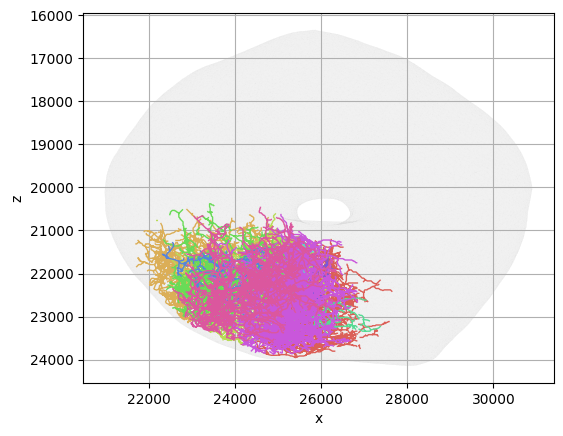

In [37]:
# verify this worked
# note: can better check with plot3d

navis.plot2d([eb_pruned, EB], view=("x", "-z"), connectors=False)

Plot neurons:   0%|          | 0/28 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

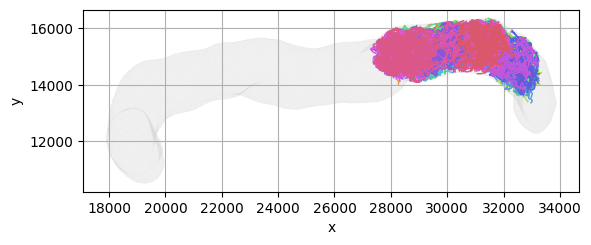

In [38]:
# verify this worked
# note: use plot3d instead for better view

navis.plot2d(
    [pb_pruned, PB],
    connectors=False
)

In [39]:
# create mesh subvolumes using pruned branches (skeleton nodes)
all_eb_pts = np.vstack([
    n.nodes[['x', 'y', 'z']].to_numpy(dtype=float)
    for n in eb_pruned
])

########################
all_pb_pts = np.vstack([
    n.nodes[['x', 'y', 'z']].to_numpy(dtype=float)
    for n in pb_pruned
])

PB_4col = trimesh.convex.convex_hull(all_pb_pts)
EB_2col = trimesh.convex.convex_hull(all_eb_pts)

# import alphashape 
# EB_2col = alphashape.alphashape(all_eb_pts, alpha=0.001)
# PB_4col = alphashape.alphashape(all_pb_pts, alpha=0.001)

In [40]:
# constrain custom meshes to be within EB and PB ROI
PB_tm = trimesh.Trimesh(
    vertices=PB.vertices,
    faces=PB.faces,
    process=False
)

EB_tm = trimesh.Trimesh(
    vertices=EB.vertices,
    faces=EB.faces,
    process=False
)

# keep only the portion of PB_4col / EB_2col that lies inside PB / EB
PB_4col = trimesh.boolean.intersection(
    [PB_4col, PB_tm],
    engine="manifold"
)
EB_2col = trimesh.boolean.intersection(
    [EB_2col, EB_tm],
    engine="manifold"
)

In [41]:
print("PB watertight:", PB_4col.is_watertight)
print("PB winding consistent:", PB_4col.is_winding_consistent)
print("PB volume:", PB_4col.volume)

print("EB watertight:", EB_2col.is_watertight)
print("EB winding consistent:", EB_2col.is_winding_consistent)
print("EB volume:", EB_2col.volume)

PB watertight: True
PB winding consistent: True
PB volume: 19874297663.020123
EB watertight: True
EB winding consistent: True
EB volume: 42929537835.529594


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='y', ylabel='z'>)

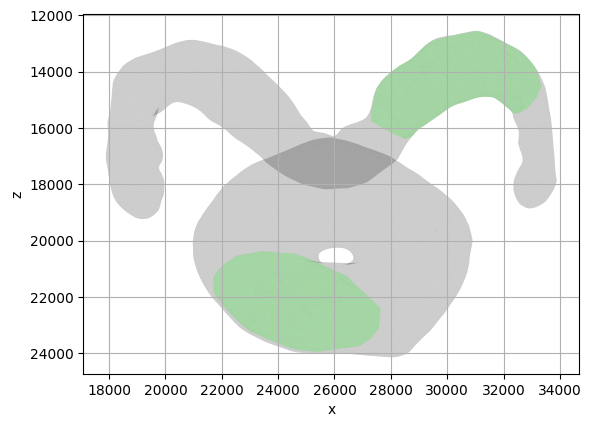

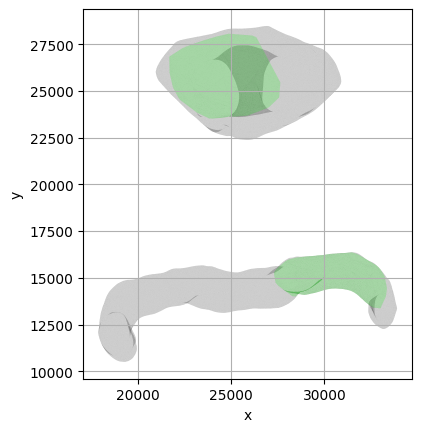

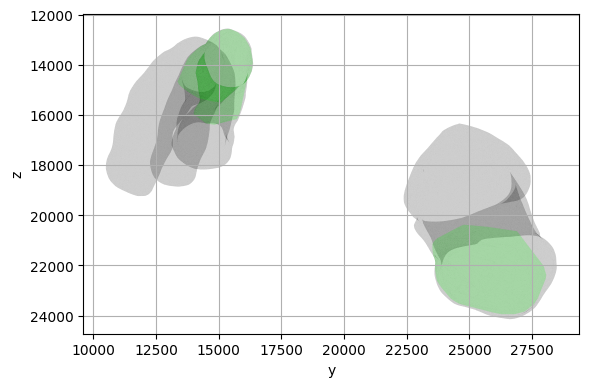

In [42]:
navis.plot2d([PB, PB_4col, EB, EB_2col], view=("x", "-z"), color=[(0, 0, 0, .1), (0, 1, 0, .1),(0, 0, 0, .1), (0, 1, 0, .1)])
navis.plot2d([PB, PB_4col, EB, EB_2col], view=("x", "y"), color=[(0, 0, 0, .1), (0, 1, 0, .1),(0, 0, 0, .1), (0, 1, 0, .1)])
navis.plot2d([PB, PB_4col, EB, EB_2col], view=("y", "-z"), color=[(0, 0, 0, .1), (0, 1, 0, .1),(0, 0, 0, .1), (0, 1, 0, .1)])

In [43]:
# build (N,3) arrays of synapse terminal coords
pre_pts = fly_syns[['x_pre', 'y_pre', 'z_pre']].to_numpy(dtype=float)
post_pts = fly_syns[['x_post', 'y_post', 'z_post']].to_numpy(dtype=float)

# test each terminal against PB and EB volumes
pre_in_eb = np.asarray(
    navis.in_volume(pre_pts, EB_2col)
)

pre_in_pb = np.asarray(
    navis.in_volume(pre_pts, PB_4col)
)

post_in_eb = np.asarray(
    navis.in_volume(post_pts, EB_2col)
)

post_in_pb = np.asarray(
    navis.in_volume(post_pts, PB_4col)
)

# inside either EB or PB
pre_in = pre_in_eb | pre_in_pb
post_in = post_in_eb | post_in_pb

# keep only synapses for which BOTH terminals are inside the union
fly_syns_in = fly_syns[pre_in & post_in].copy()

In [55]:
# subvolumes aren't perfect, so remove any neurons that aren't included in bee 
# but maybe innervate the subvolume partially
fly_filt = fly_syns_in.copy()
eb_pat = r'EPG_R1|PEG_R1|EPG_L3|PEG_L3|EPG_L4|PEG_L4|EPG_R7|PEG_R7|PEN_a_L4|PEN_a_L5|PEN_b_L4|PEN_a_R7|PEN_b_R7'

eb_filt = (
    ((fly_filt['roi_pre'] == 'EB') &
     (fly_filt['type_pre_col'].str.contains(eb_pat, regex=True, na=False))) |
    ((fly_filt['roi_post'] == 'EB') &
     (fly_filt['type_post_col'].str.contains(eb_pat, regex=True, na=False)))
)

fly_filt = fly_filt[~eb_filt].copy()


pb_pat = r'EPG_L2|PEG_L2|EPG_L7|PEG_L7|PEN_a_L2|PEN_b_L2|PEN_a_L7|PEN_b_L7'

pb_filt = (
    ((fly_filt['roi_pre'] == 'PB') &
     (fly_filt['type_pre_col'].str.contains(pb_pat, regex=True, na=False))) |
    ((fly_filt['roi_post'] == 'PB') &
     (fly_filt['type_post_col'].str.contains(pb_pat, regex=True, na=False)))
)

fly_filt = fly_filt[~pb_filt].copy()

In [57]:
# verify everything worked (more verfication tests below)
d7 = fly_filt[fly_filt['bodyId_pre'].isin([910442782])]
d7_pre = d7[['x_pre', 'y_pre', 'z_pre']].rename(columns={'x_pre': 'x', 'y_pre': 'y', 'z_pre': 'z'})
d7_post = d7[['x_post', 'y_post', 'z_post']].rename(columns={'x_post': 'x', 'y_post': 'y', 'z_post': 'z'})

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

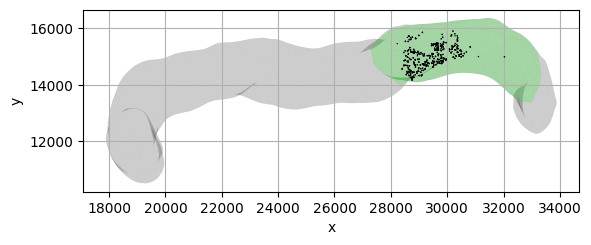

In [58]:
navis.plot2d([PB, PB_4col, d7_pre], color=[(0, 0, 0, .1), (0, 1, 0, .1)])

In [59]:
# export ... see past next section for additional checks that synapse filtering by volume is accurate
fly_filt.to_csv('../../data/fly_hemibrain_beeROI_syntable.csv', index = False)

### make connectivity table from fly bee ROI filtered table


In [48]:
fly_count = fly_filt.copy()

fly_count = fly_count[fly_count['bodyId_pre'] != fly_count['bodyId_post']] #remove autapses

df = fly_count[['bodyId_pre', 'bodyId_post', 'pre_name', 'post_name', 'type_pre_col', 'type_post_col', 'type_pre', 'type_post', 'roi_pre', 'roi_post']]

'''keep NaN partners so that relative weight score is calculated with total synapse numbers 
makes it comparable to the fruit fly value_counts() here counts how many times each unique 
combination of the 4 columns occurs in the df'''
fly_conn = df.value_counts(dropna=False)

# Reset index turns MultiIndex into columns, and .rename() makes column names explicit
fly_conn = fly_conn.reset_index().rename(
    columns={
        0: 'count'  # This is the name of the column created by value_counts()
    }
)

fly_conn

,bodyId_pre,bodyId_post,pre_name,post_name,type_pre_col,type_post_col,type_pre,type_post,roi_pre,roi_post,count
0,910783961,5813070465,Delta7_L3R6_910783961,PEN_b_L3_5813070465,Delta7_L3R6,PEN_b_L3,Delta7,PEN_b,PB,PB,180
1,911565419,5813070465,Delta7_L3R6_911565419,PEN_b_L3_5813070465,Delta7_L3R6,PEN_b_L3,Delta7,PEN_b,PB,PB,141
2,634608104,572870540,PEN_a_L2_634608104,EPG_L1_572870540,PEN_a_L2,EPG_L1,PEN_a,EPG,EB,EB,126
3,880875736,1631450739,Delta7_L5R4_880875736,PEN_b_L5_1631450739,Delta7_L5R4,PEN_b_L5,Delta7,PEN_b,PB,PB,125
4,665314820,942587380,EPG_L4_665314820,PEG_L4_942587380,EPG_L4,PEG_L4,EPG,PEG,PB,PB,119
...,...,...,...,...,...,...,...,...,...,...,...
15861,1261086823,1261427999,ER3dc_L_1261086823,ER3dd_L_1261427999,ER3dc_L,ER3dd_L,ER3d,ER3d,EB,EB,1
15862,1261086823,1261427885,ER3dc_L_1261086823,ER3db_R_1261427885,ER3dc_L,ER3db_R,ER3d,ER3d,EB,EB,1
15863,1261086823,1199017128,ER3dc_L_1261086823,ER2b_L_1199017128,ER3dc_L,ER2b_L,ER3d,ER2,EB,EB,1
15864,1261086823,1198943369,ER3dc_L_1261086823,ER2d_R_1198943369,ER3dc_L,ER2d_R,ER3d,ER2,EB,EB,1


In [49]:
fly_conn.to_csv('../../data/fly_hemibrain_beeROI_conntable.csv', index=False)

### more synapse count verification
- fly_syns is full synapse table
- fly_filt and fly_count are synapses located within EB and PB volumes defined above

In [50]:
# The connections below shouldn't have been filtered out. 
# So in next two blocks I compare counts in unfiltered table to filtered by ROI table

epgs = ['EPG_L3', 'EPG_L4', 'EPG_L5', 'EPG_L6']

# EPG -> Delta7
epg_to_d7 = fly_syns[
    fly_syns['type_pre_col'].isin(epgs) &
    fly_syns['type_post_col'].str.startswith('Delta7_', na=False)
]

# Delta7 -> EPG
d7_to_epg = fly_syns[
    fly_syns['type_pre_col'].str.startswith('Delta7_', na=False) &
    fly_syns['type_post_col'].isin(epgs)
]

print('EPG -> Delta7:', len(epg_to_d7))
print('Delta7 -> EPG:', len(d7_to_epg))

EPG -> Delta7: 4407
Delta7 -> EPG: 1824


In [51]:
fly_check = fly_filt.copy()

epgs = ['EPG_L3', 'EPG_L4', 'EPG_L5', 'EPG_L6']

# EPG -> Delta7
epg_to_d7 = fly_check[
    fly_check['type_pre_col'].isin(epgs) &
    fly_check['type_post_col'].str.startswith('Delta7_', na=False)
]

# Delta7 -> EPG
d7_to_epg = fly_check[
    fly_check['type_pre_col'].str.startswith('Delta7_', na=False) &
    fly_check['type_post_col'].isin(epgs)
]

print('EPG -> Delta7:', len(epg_to_d7))
print('Delta7 -> EPG:', len(d7_to_epg))

EPG -> Delta7: 4401
Delta7 -> EPG: 1812


***check Delta7 → EPG_L5 matches expected from neuprint***

In [52]:
fly_syns[fly_syns['type_pre_col'].str.contains(r'EPG_L2') & fly_syns['type_post_col'].str.contains(r'EPG_L2')]

,bodyId_pre,bodyId_post,roi_pre,roi_post,x_pre,y_pre,z_pre,x_post,y_post,z_post,confidence_pre,confidence_post,type_pre,instance_pre,type_post,instance_post,type_pre_col,type_post_col,pre_name,post_name
25807,912545106,697001770,EB,EB,23130,26567,21829,23145,26550,21835,0.900,0.899517,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_912545106,EPG_L2_697001770
25808,912545106,697001770,EB,EB,22971,25375,21305,22933,25370,21285,0.870,0.450113,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_912545106,EPG_L2_697001770
25809,912545106,697001770,EB,EB,23076,26351,22096,23062,26370,22100,0.890,0.371000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_912545106,EPG_L2_697001770
25810,912545106,697001770,EB,EB,23017,24817,21727,23013,24811,21700,0.715,0.886000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_912545106,EPG_L2_697001770
25811,912545106,697001770,EB,EB,23042,24769,21726,23015,24772,21719,0.663,0.890000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_912545106,EPG_L2_697001770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66685,697001770,912545106,EB,EB,23923,24974,22995,23909,24976,22968,0.878,0.661000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_697001770,EPG_L2_912545106
66686,697001770,912545106,EB,EB,23049,26244,22466,23050,26246,22479,0.854,0.990000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_697001770,EPG_L2_912545106
66687,697001770,912545106,EB,EB,22714,26644,21576,22699,26660,21562,0.823,0.955000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_697001770,EPG_L2_912545106
66688,697001770,912545106,EB,EB,23338,25212,22403,23354,25201,22395,0.727,0.963000,EPG,EPG(PB08)_L2,EPG,EPG(PB08)_L2,EPG_L2,EPG_L2,EPG_L2_697001770,EPG_L2_912545106


In [53]:
pre_id = 912545106 # use bodyIds of neurons with guarenteed connectivity in single PB or EB column
post_id = 697001770 # Here I use EPG_L2 for both pre and post

pair = fetch_synapse_connections(
    NC(bodyId=pre_id),
    NC(bodyId=post_id),
    SC(rois=['PB', 'EB', 'NO'], primary_only=True)
)

print("All neuPrint synapses:", len(pair))

  0%|          | 0/46 [00:00<?, ?it/s]

All neuPrint synapses: 46


In [54]:
# output from this cell should match above number
pre_pts = pair[['x_pre', 'y_pre', 'z_pre']].to_numpy(float)
post_pts = pair[['x_post', 'y_post', 'z_post']].to_numpy(float)

pre_in = (
    np.asarray(navis.in_volume(pre_pts, EB_2col, backend='scipy', validate=False)) |
    np.asarray(navis.in_volume(pre_pts, PB_4col, backend='scipy', validate=False))
)

post_in = (
    np.asarray(navis.in_volume(post_pts, EB_2col, backend='scipy', validate=False)) |
    np.asarray(navis.in_volume(post_pts, PB_4col, backend='scipy', validate=False))
) 

pair_inside = pair[pre_in & post_in]

print("All neuPrint synapses:", len(pair))
print("Inside EB/PB subvolume:", len(pair_inside))

All neuPrint synapses: 46
Inside EB/PB subvolume: 46


### obtain ER counts for fly (for Figure 1 stacked bar chart)

In [42]:
fly_count = pd.read_csv("../../data/fly_hemibrain_all_hd_cells_conntable.csv")

In [43]:
# this function assigns a BU sub-roi to ER neurons 
# based on Hulse et al. 2021 Table 5

def normalize_er_types(df, pre_col='type_pre', post_col='type_post'):
    pattern_map = {
        r'^ER1.*': 'ER1_3a_LAL',
        r'^ER2.*': 'ER_BUs',
        r'^ER3w.*': 'ER_BUs',
        r'^ER4d.*': 'ER_BUs',
        r'^ER3a.*': 'ER1_3a_LAL',
        r'^ER3d.*': 'ER_BUi',
        r'^ER3p.*': 'ER_BUi',
        r'^ER3m.*': 'ER_BUi',
        r'^ER4m.*': 'ER_BUa',
        r'^ER5.*':  'ER_BUs',
        r'^ER6.*': "ER_BUa",
        r'^ExR.*':  'ExR'
    }
    
    # Apply replacements only to new columns
    for pattern, replacement in pattern_map.items():
        df[pre_col] = df[pre_col].str.replace(pattern, replacement, regex=True)
        df[post_col] = df[post_col].str.replace(pattern, replacement, regex=True)


    return df

In [44]:
# obtain ER counts for fly (for Figure 1 stacked bar chart)
fly_er = normalize_er_types(fly_count)


# keep only rows where BOTH partners are ER neurons
er_df = fly_er[
    fly_er["pre_name"].str.contains("ER", na=False) &
    fly_er["post_name"].str.contains("ER", na=False)
].copy()


pre_neurons = er_df[["pre_name", "type_pre"]].copy()
pre_neurons.columns = ["neuron", "roi"]

post_neurons = er_df[["post_name", "type_post"]].copy()
post_neurons.columns = ["neuron", "roi"]

all_neurons = pd.concat([pre_neurons, post_neurons], ignore_index=True)


all_neurons = all_neurons.drop_duplicates()

conflicts = (
    all_neurons.groupby("neuron")["roi"]
    .nunique()
    .reset_index(name="n_roi")
)
conflicts = conflicts[conflicts["n_roi"] > 1]

all_neurons["side"] = np.where(
    all_neurons["neuron"].str.contains("_R", na=False), "right",
    np.where(all_neurons["neuron"].str.contains("_L", na=False), "left", np.nan)
)


all_neurons = all_neurons.dropna(subset=["side"])

# Count unique neurons by side and ROI
cell_counts = (
    all_neurons.groupby(["side", "roi"], as_index=False)
    .size()
    .rename(columns={"size": "cell_count"})
)

print(cell_counts)

    side         roi  cell_count
0   left  ER1_3a_LAL          29
1   left      ER_BUa           6
2   left      ER_BUi          39
3   left      ER_BUs          53
4  right  ER1_3a_LAL          27
5  right      ER_BUa           7
6  right      ER_BUi          41
7  right      ER_BUs          54


In [45]:
cell_counts[cell_counts["side"].str.contains(r"right")] # most complete

,side,roi,cell_count
4,right,ER1_3a_LAL,27
5,right,ER_BUa,7
6,right,ER_BUi,41
7,right,ER_BUs,54


In [46]:
cg = cell_counts.groupby("side", as_index=False)["cell_count"].sum()

cg

'''There are 129 right side ER in hemibrain and 139 right side ER cells in FAFB (not shown here)'''

'There are 129 right side ER in hemibrain and 139 right side ER cells in FAFB (not shown here)'

In [47]:
''' to obtain TuBu counts I used following Neo4j Cypher query on the neuprint.janelia.org 
hemibrain:v1.2.1:

total count
MATCH (n:Neuron)
WHERE n.type CONTAINS "TuBu"
  AND n.instance CONTAINS "_R"
RETURN count(n)

74

-------------------
TUBU map:
"BUs"

MATCH (n:Neuron)
WHERE any(x IN ["TuBu06","TuBu07","TuBu08","TuBu09","TuBu10"]
          WHERE n.instance CONTAINS x)
  AND n.instance ENDS WITH "_R"
RETURN count(n)

41

"BUi"
MATCH (n:Neuron)
WHERE any(x IN ["TuBu02","TuBu03","TuBu04","TuBu05"]
          WHERE n.instance CONTAINS x)
  AND n.instance ENDS WITH "_R"
RETURN count(n)

28

"BUa"
MATCH (n:Neuron)
WHERE any(x IN ["TuBu01"]
          WHERE n.instance CONTAINS x)
  AND n.instance ENDS WITH "_R"
RETURN count(n)

5
'''

' to obtain TuBu counts I used following Neo4j Cypher query on the neuprint.janelia.org \nhemibrain:v1.2.1:\n\ntotal count\nMATCH (n:Neuron)\nWHERE n.type CONTAINS "TuBu"\n  AND n.instance CONTAINS "_R"\nRETURN count(n)\n\n74\n\n-------------------\nTUBU map:\n"BUs"\n\nMATCH (n:Neuron)\nWHERE any(x IN ["TuBu06","TuBu07","TuBu08","TuBu09","TuBu10"]\n          WHERE n.instance CONTAINS x)\n  AND n.instance ENDS WITH "_R"\nRETURN count(n)\n\n41\n\n"BUi"\nMATCH (n:Neuron)\nWHERE any(x IN ["TuBu02","TuBu03","TuBu04","TuBu05"]\n          WHERE n.instance CONTAINS x)\n  AND n.instance ENDS WITH "_R"\nRETURN count(n)\n\n28\n\n"BUa"\nMATCH (n:Neuron)\nWHERE any(x IN ["TuBu01"]\n          WHERE n.instance CONTAINS x)\n  AND n.instance ENDS WITH "_R"\nRETURN count(n)\n\n5\n'